# W4 — COS pricing check

This notebook checks the first COS pricing prototype for VIX options.

The code is stored in:

- `src/models/cir.py`
- `src/pricing/vix_cos.py`

The goal here is not full market calibration yet. The goal is to check that the COS prototype runs, produces non-negative VIX call and put prices, and can be compared with the W3 Monte Carlo result.

In [10]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.models.cir import (
    CIRParams,
    cir_terminal_moments,
    cir_truncation_interval,
    vix_affine_coefficients,
    vix_level_from_variance,
)

from src.pricing.vix_cos import (
    COSSettings,
    compare_vix_call_cos_with_mc,
    price_vix_call_cos,
    price_vix_put_cos,
)

In [11]:
params = CIRParams(
    v0=0.04,
    kappa=2.0,
    theta=0.04,
    sigma_v=0.5,
)

settings = COSSettings(
    n_terms=128,
    truncation_std_width=8.0,
    coefficient_grid_size=4096,
)

option_maturity = 30 / 365
r = 0.03
delta = 30 / 365

params, settings

(CIRParams(v0=0.04, kappa=2.0, theta=0.04, sigma_v=0.5),
 COSSettings(n_terms=128, truncation_std_width=8.0, coefficient_grid_size=4096))

In [12]:
a, b = vix_affine_coefficients(
    params=params,
    delta=delta,
)

mean_v, var_v = cir_terminal_moments(
    params=params,
    maturity=option_maturity,
)

lower, upper = cir_truncation_interval(
    params=params,
    maturity=option_maturity,
    std_width=settings.truncation_std_width,
)

setup_table = pd.DataFrame(
    [
        {
            "A coefficient": a,
            "B coefficient": b,
            "E[v_T]": mean_v,
            "Var[v_T]": var_v,
            "lower truncation": lower,
            "upper truncation": upper,
            "VIX at theta": vix_level_from_variance(params.theta, params, delta),
        }
    ]
)

setup_table

,A coefficient,B coefficient,E[v_T],Var[v_T],lower truncation,upper truncation,VIX at theta
0,0.003115,0.922133,0.04,0.0007,0.0,0.251732,20.0


In [13]:
call_result = price_vix_call_cos(
    params=params,
    option_maturity=option_maturity,
    strike=20.0,
    r=r,
    delta=delta,
    settings=settings,
)

put_result = price_vix_put_cos(
    params=params,
    option_maturity=option_maturity,
    strike=20.0,
    r=r,
    delta=delta,
    settings=settings,
)

pd.DataFrame([call_result | put_result])

,vix_call_cos_price,expected_payoff,strike,lower_truncation,upper_truncation,n_terms,vix_put_cos_price
0,2.008969,2.956917,20.0,0.0,0.251732,128,2.949635


In [14]:
w3_mc_vix_call_price = 1.984952

comparison = compare_vix_call_cos_with_mc(
    cos_price=call_result["vix_call_cos_price"],
    mc_price=w3_mc_vix_call_price,
)

pd.DataFrame([comparison])

,cos_price,mc_price,absolute_difference,relative_difference
0,2.008969,1.984952,0.024017,0.0121


In [15]:
strikes = [10, 15, 20, 25, 30, 35, 40]

rows = []

for strike in strikes:
    call = price_vix_call_cos(
        params=params,
        option_maturity=option_maturity,
        strike=float(strike),
        r=r,
        delta=delta,
        settings=settings,
    )

    put = price_vix_put_cos(
        params=params,
        option_maturity=option_maturity,
        strike=float(strike),
        r=r,
        delta=delta,
        settings=settings,
    )

    rows.append(
        {
            "strike": strike,
            "call_cos_price": call["vix_call_cos_price"],
            "put_cos_price": put["vix_put_cos_price"],
        }
    )

strike_table = pd.DataFrame(rows)
strike_table

,strike,call_cos_price,put_cos_price
0,10,9.158711,0.124004
1,15,4.932858,0.885837
2,20,2.008969,2.949635
3,25,0.571070,6.499422
4,30,0.106450,11.022488
5,35,0.012447,15.916172
6,40,0.000881,20.892292


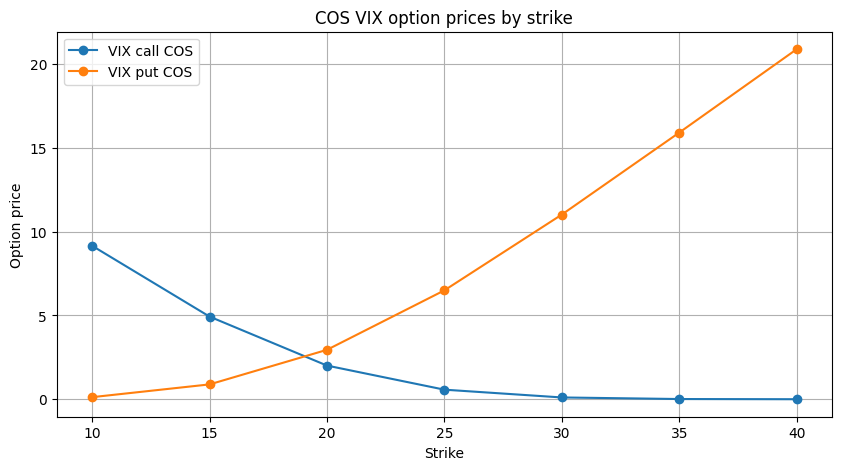

In [16]:
plt.figure(figsize=(10, 5))

plt.plot(
    strike_table["strike"],
    strike_table["call_cos_price"],
    marker="o",
    label="VIX call COS",
)

plt.plot(
    strike_table["strike"],
    strike_table["put_cos_price"],
    marker="o",
    label="VIX put COS",
)

plt.title("COS VIX option prices by strike")
plt.xlabel("Strike")
plt.ylabel("Option price")
plt.grid(True)
plt.legend()
plt.show()

## Convergence study — number of COS terms N


In [17]:
from src.pricing.w4_validation import (
    convergence_over_n_terms,
    convergence_over_truncation_width,
    cross_validate_with_mc,
    speed_benchmark_cos,
    model_vix_term_structure,
    density_recovery_check,
)

df_n = convergence_over_n_terms(
    params=params,
    option_maturity=option_maturity,
    strike=20.0,
    r=r,
    delta=delta,
    n_terms_grid=[4, 8, 16, 32, 64, 128, 256, 512, 1024],
    reference_n_terms=2048,
)

print(f"Reference price (N=2048): {df_n.attrs['reference_price']:.6f}")
df_n[["n_terms", "cos_price", "abs_error", "rel_error"]]

Reference price (N=2048): 2.008978


,n_terms,cos_price,abs_error,rel_error
0,4,2.126673,0.117695,0.058585
1,8,2.018934,0.009956,0.004956
2,16,2.010714,0.001737,0.000864
3,32,2.008999,0.000021,0.000011
4,64,2.008968,0.000009,0.000005
5,128,2.008969,0.000008,0.000004
6,256,2.008971,0.000007,0.000003
7,512,2.008971,0.000006,0.000003
8,1024,2.008971,0.000006,0.000003


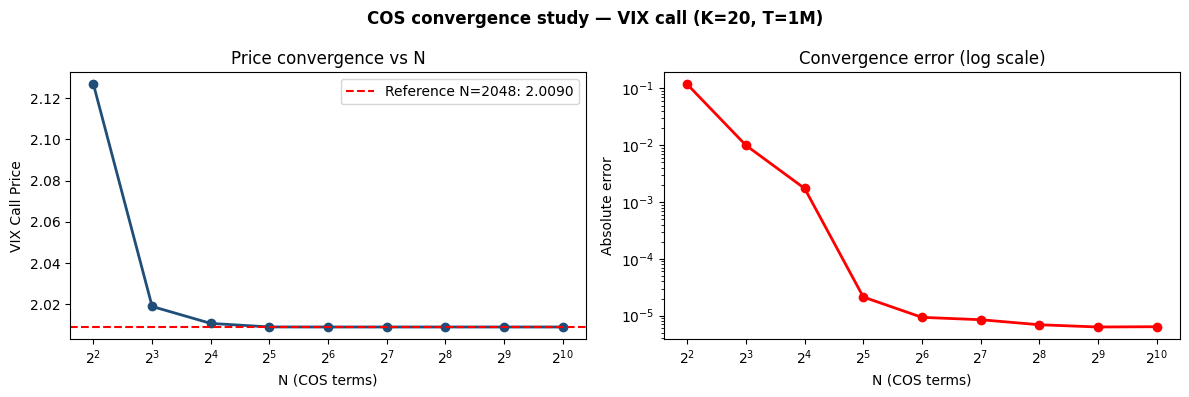

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(df_n["n_terms"], df_n["cos_price"], marker="o", color="#1f4e79", lw=2)
axes[0].axhline(df_n.attrs["reference_price"], color="red", ls="--", lw=1.5,
                label=f"Reference N=2048: {df_n.attrs['reference_price']:.4f}")
axes[0].set_xscale("log", base=2)
axes[0].set_xlabel("N (COS terms)")
axes[0].set_ylabel("VIX Call Price")
axes[0].set_title("Price convergence vs N")
axes[0].legend()

valid = df_n["abs_error"] > 0
axes[1].plot(df_n.loc[valid, "n_terms"], df_n.loc[valid, "abs_error"],
             marker="o", color="red", lw=2)
axes[1].set_xscale("log", base=2)
axes[1].set_yscale("log")
axes[1].set_xlabel("N (COS terms)")
axes[1].set_ylabel("Absolute error")
axes[1].set_title("Convergence error (log scale)")

plt.suptitle("COS convergence study — VIX call (K=20, T=1M)", fontweight="bold")
plt.tight_layout()
plt.show()

## Convergence study — truncation interval [a, b]

In [20]:
df_w = convergence_over_truncation_width(
    params=params,
    option_maturity=option_maturity,
    strike=20.0,
    r=r,
    delta=delta,
    std_widths=[2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 10.0, 12.0],
    n_terms=256,
    reference_std_width=12.0,
)

df_w[["std_width", "lower", "upper", "cos_price", "abs_error"]]

,std_width,lower,upper,cos_price,abs_error
0,2.0,0.0,0.092933,1.763985,0.244990
1,3.0,0.0,0.119399,1.959020,0.049954
2,4.0,0.0,0.145866,1.999729,0.009245
3,5.0,0.0,0.172332,2.007375,0.001600
4,6.0,0.0,0.198799,2.008714,0.000261
5,7.0,0.0,0.225265,2.008936,0.000039
6,8.0,0.0,0.251732,2.008971,0.000004
7,10.0,0.0,0.304665,2.008978,0.000004
8,12.0,0.0,0.357598,2.008975,0.000000


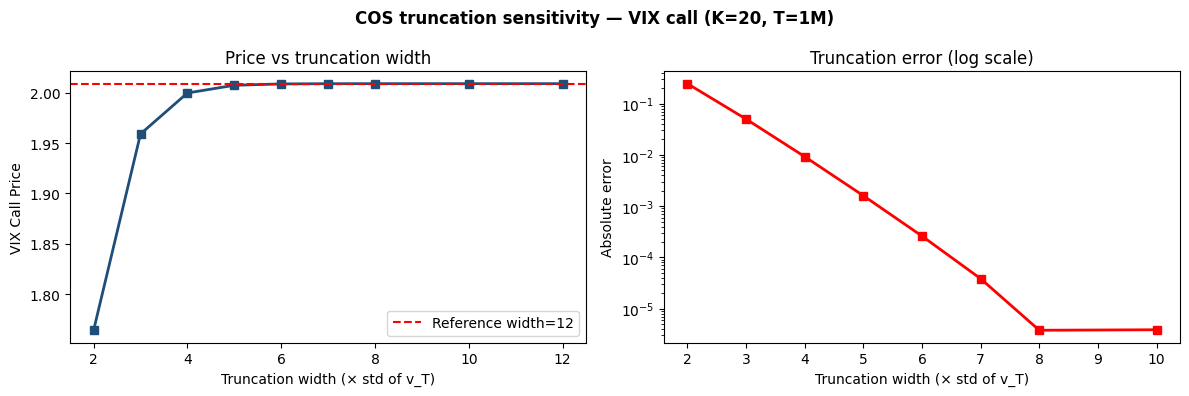

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(df_w["std_width"], df_w["cos_price"], marker="s", color="#1f4e79", lw=2)
axes[0].axhline(df_w.attrs["reference_price"], color="red", ls="--", lw=1.5, label="Reference width=12")
axes[0].set_xlabel("Truncation width (× std of v_T)")
axes[0].set_ylabel("VIX Call Price")
axes[0].set_title("Price vs truncation width")
axes[0].legend()

valid_w = df_w["abs_error"] > 0
axes[1].plot(df_w.loc[valid_w, "std_width"], df_w.loc[valid_w, "abs_error"],
             marker="s", color="red", lw=2)
axes[1].set_yscale("log")
axes[1].set_xlabel("Truncation width (× std of v_T)")
axes[1].set_ylabel("Absolute error")
axes[1].set_title("Truncation error (log scale)")

plt.suptitle("COS truncation sensitivity — VIX call (K=20, T=1M)", fontweight="bold")
plt.tight_layout()
plt.show()

## COS vs Monte Carlo cross-validation


In [23]:
STRIKES = [10.0, 15.0, 20.0, 25.0, 30.0, 35.0, 40.0]

MC_FUTURES_PRICE = 19.01
MC_CALL_PRICES   = [9.95, 5.16, 1.98, 0.42, 0.06, 0.01, 0.00]
MC_PUT_PRICES    = [0.00, 0.01, 0.97, 5.41, 10.99, 16.95, 21.94]

xval = cross_validate_with_mc(
    params=params,
    strikes=STRIKES,
    option_maturity=option_maturity,
    mc_call_prices=MC_CALL_PRICES,
    mc_put_prices=MC_PUT_PRICES,
    mc_futures_price=MC_FUTURES_PRICE,
    r=r,
    delta=delta,
)

print("Futures:")
print(xval["futures"].to_string(index=False))
print("\nOptions:")
xval["options"][["strike", "cos_call", "mc_call", "call_abs_err",
                 "cos_put",  "mc_put",  "put_abs_err"]]

Futures:
 cos_futures  mc_futures  abs_error  rel_error_pct
    19.00981       19.01    0.00019       0.000998

Options:


,strike,cos_call,mc_call,call_abs_err,cos_put,mc_put,put_abs_err
0,10.0,9.158696,9.95,0.791304,0.124258,0.00,0.124258
1,15.0,4.932865,5.16,0.227135,0.886114,0.01,0.876114
2,20.0,2.008971,1.98,0.028971,2.949906,0.97,1.979906
3,25.0,0.571072,0.42,0.151072,6.499693,5.41,1.089693
4,30.0,0.106450,0.06,0.046450,11.022758,10.99,0.032758
5,35.0,0.012447,0.01,0.002447,15.916442,16.95,1.033558
6,40.0,0.000881,0.00,0.000881,20.892562,21.94,1.047438


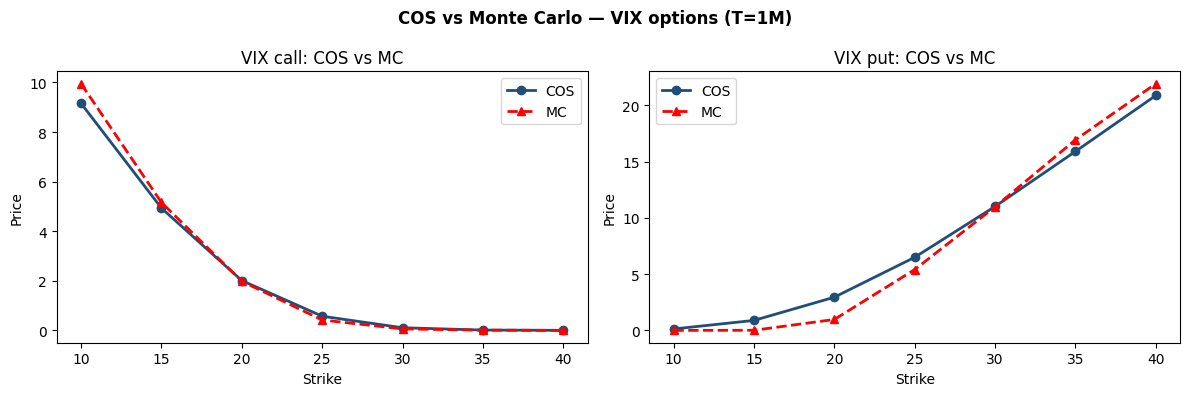

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
opt = xval["options"]

axes[0].plot(opt["strike"], opt["cos_call"], marker="o", color="#1f4e79", lw=2, label="COS")
axes[0].plot(opt["strike"], opt["mc_call"],  marker="^", color="red", lw=2, ls="--", label="MC")
axes[0].set_xlabel("Strike")
axes[0].set_ylabel("Price")
axes[0].set_title("VIX call: COS vs MC")
axes[0].legend()

axes[1].plot(opt["strike"], opt["cos_put"], marker="o", color="#1f4e79", lw=2, label="COS")
axes[1].plot(opt["strike"], opt["mc_put"],  marker="^", color="red", lw=2, ls="--", label="MC")
axes[1].set_xlabel("Strike")
axes[1].set_ylabel("Price")
axes[1].set_title("VIX put: COS vs MC")
axes[1].legend()

plt.suptitle("COS vs Monte Carlo — VIX options (T=1M)", fontweight="bold")
plt.tight_layout()
plt.show()

## Speed benchmark

In [25]:
bench = speed_benchmark_cos(
    params=params,
    option_maturity=option_maturity,
    strike=20.0,
    r=r,
    delta=delta,
    cos_settings=settings,
    n_repeats=500,
)

typical_mc_time_s = 3.0
speedup = typical_mc_time_s / bench["cos_median_s"]

print(f"COS median:  {bench['cos_median_s']*1000:.2f} ms per price")
print(f"COS minimum: {bench['cos_min_s']*1000:.2f} ms per price")
print(f"MC typical:  {typical_mc_time_s*1000:.0f} ms  (100k paths)")
print(f"Speedup:     {speedup:.0f}x")

COS median:  9.86 ms per price
COS minimum: 8.28 ms per price
MC typical:  3000 ms  (100k paths)
Speedup:     304x


## VIX futures term structure

In [26]:
model_ts = model_vix_term_structure(
    params=params,
    r=r,
    delta=delta,
    cos_settings=settings,
)

model_ts[["maturity_months", "model_futures_price", "expected_vix"]]

,maturity_months,model_futures_price,expected_vix
0,1.0,18.998821,19.046377
1,2.0,18.349623,18.441601
2,3.0,17.947423,18.082534
3,4.0,17.686070,17.863818
4,5.0,17.506054,17.726253
5,6.0,17.374814,17.637400
6,7.0,17.273850,17.578803
7,8.0,17.192220,17.539526


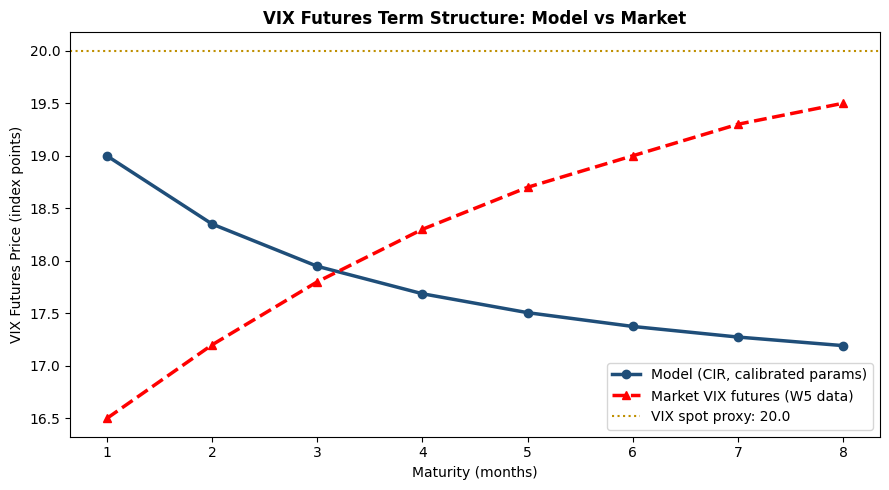

In [28]:
import numpy as np

# Market VIX futures data from W5 (replace with actual W5 dataset)
market_months = [1, 2, 3, 4, 5, 6, 7, 8]
market_prices = [16.5, 17.2, 17.8, 18.3, 18.7, 19.0, 19.3, 19.5]

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(model_ts["maturity_months"], model_ts["model_futures_price"],
        marker="o", color="#1f4e79", lw=2.5, label="Model (CIR, calibrated params)")
ax.plot(market_months, market_prices,
        marker="^", color="red", lw=2.5, ls="--", label="Market VIX futures (W5 data)")
ax.axhline(100 * np.sqrt(params.v0), color="#bf8f00", lw=1.5, ls=":",
           label=f"VIX spot proxy: {100*np.sqrt(params.v0):.1f}")

ax.set_xlabel("Maturity (months)")
ax.set_ylabel("VIX Futures Price (index points)")
ax.set_title("VIX Futures Term Structure: Model vs Market", fontweight="bold")
ax.set_xticks(range(1, 9))
ax.legend()

plt.tight_layout()
plt.show()

## Density recovery


Density integral: 1.000062  (target: 1.0)
All values ≥ 0:   True


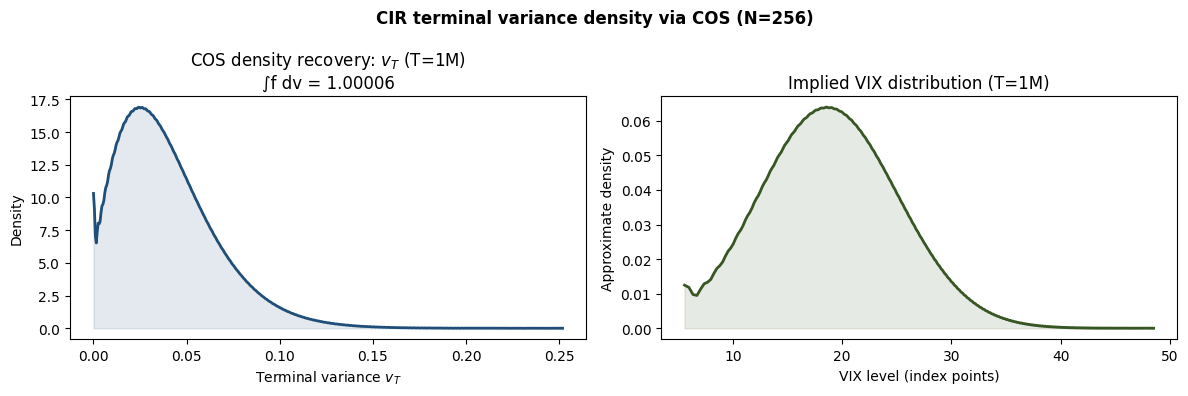

In [29]:
dens = density_recovery_check(params, maturity=option_maturity, n_terms=256)

print(f"Density integral: {dens.attrs['integral']:.6f}  (target: 1.0)")
print(f"All values ≥ 0:   {(dens['density_v'] >= 0).all()}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(dens["variance"], dens["density_v"], color="#1f4e79", lw=2)
axes[0].fill_between(dens["variance"], dens["density_v"], alpha=0.12, color="#1f4e79")
axes[0].set_xlabel("Terminal variance $v_T$")
axes[0].set_ylabel("Density")
axes[0].set_title(f"COS density recovery: $v_T$ (T=1M)\n∫f dv = {dens.attrs['integral']:.5f}")

axes[1].plot(dens["vix_level"], dens["density_vix_approx"], color="#375623", lw=2)
axes[1].fill_between(dens["vix_level"], dens["density_vix_approx"], alpha=0.12, color="#375623")
axes[1].set_xlabel("VIX level (index points)")
axes[1].set_ylabel("Approximate density")
axes[1].set_title("Implied VIX distribution (T=1M)")

plt.suptitle("CIR terminal variance density via COS (N=256)", fontweight="bold")
plt.tight_layout()
plt.show()

## Short note

The COS prototype produces VIX call and put prices using the terminal CIR variance distribution.

The W3 Monte Carlo result is used as the first benchmark for the VIX call price. At this stage, the goal is to check numerical behaviour and consistency, not final market calibration.

The final version can later be improved by using closed-form COS payoff coefficients, calibration to market data, and a more detailed comparison with Monte Carlo.